In [28]:
import numpy as np
import pandas as pd
import sklearn as sk
import matplotlib # I import kust mathplotlib cuz mathplotlib.pyplot dont have "__version__"
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix ,  classification_report , accuracy_score
from sklearn.linear_model import Perceptron

In [29]:
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sk.__version__)
print("Matplotlib:", matplotlib.__version__)

NumPy: 2.4.1
Pandas: 3.0.0
Scikit-learn: 1.8.0
Matplotlib: 3.10.8


In [30]:
# Problem 6.2

In [31]:
X_train = np.array([
    [0.9 , 0.8],
    [0.2 , 0.1],
    [0.7 , 0.9],
    [0.3 , 0.2],
    [0.8 , 0.7],
    [0.1 , 0.3]
])

In [32]:
y_train = np.array([1 , 0 , 1 , 0 , 1 ,0])


In [33]:
#A)

In [34]:
model = Perceptron(
    eta0 = 1.0, #learning rate
    max_iter = 100, # maximum epochs
    random_state = 42, #for reproducinility
    verbose = 1 #print progress
)

In [35]:
model.fit(X_train , y_train)

-- Epoch 1
Norm: 0.85, NNZs: 2, Bias: 0.000000, T: 6, Avg. loss: 0.223333, Objective: 0.223333
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 1.70, NNZs: 2, Bias: 0.000000, T: 12, Avg. loss: 0.118333, Objective: 0.118333
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 1.49, NNZs: 2, Bias: -1.000000, T: 18, Avg. loss: 0.060000, Objective: 0.060000
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 1.49, NNZs: 2, Bias: -1.000000, T: 24, Avg. loss: 0.000000, Objective: 0.000000
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 1.49, NNZs: 2, Bias: -1.000000, T: 30, Avg. loss: 0.000000, Objective: 0.000000
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 1.49, NNZs: 2, Bias: -1.000000, T: 36, Avg. loss: 0.000000, Objective: 0.000000
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 1.49, NNZs: 2, Bias: -1.000000, T: 42, Avg. loss: 0.000000, Objective: 0.000000
Total training time: 0.00 seconds.
-- Epoch 8
Norm: 1.49, NNZs: 2, Bias: -1.000000, T: 48, Avg. loss: 0.000000, Ob

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",100
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",1
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",42


In [36]:
#B)

In [37]:
#Displaying learned parameters
print("Learned weights (w_1 , w_2):" ,  model.coef_)
print("Learned bias(b):" , model.intercept_)
print("Numner of iterations:" , model.n_iter_)

Learned weights (w_1 , w_2): [[1.  1.1]]
Learned bias(b): [-1.]
Numner of iterations: 9


In [38]:
#Generating predictions
y_pred = model.predict(X_train)

In [39]:
#Calculating accuracy
acc = accuracy_score(y_train , y_pred)
print("Training accuracy:" , acc * 100 , "%")

Training accuracy: 100.0 %


In [40]:
#Predictions VS Actual
print("Sample-by-sample results:")
for i in range (len(y_train)):
    if y_train[i] == y_pred[i]:
        status = "Correct"
    else:
        status = "Incorrect"
    print( "Sample = " , i + 1 , ":")
    print( "Actual = " , y_train[i])
    print( "Predicted = " , y_pred[i] , "--" , status)

Sample-by-sample results:
Sample =  1 :
Actual =  1
Predicted =  1 -- Correct
Sample =  2 :
Actual =  0
Predicted =  0 -- Correct
Sample =  3 :
Actual =  1
Predicted =  1 -- Correct
Sample =  4 :
Actual =  0
Predicted =  0 -- Correct
Sample =  5 :
Actual =  1
Predicted =  1 -- Correct
Sample =  6 :
Actual =  0
Predicted =  0 -- Correct


In [41]:
#Generating and displaying confusion matrix

Confusion matrix
[[3 0]
 [0 3]]


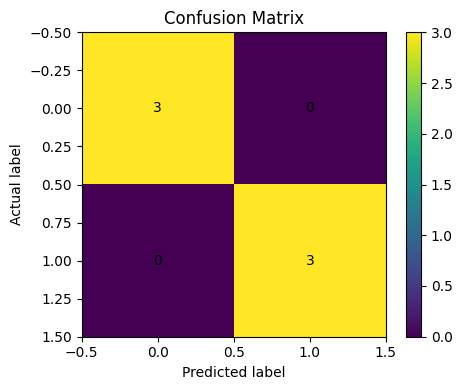

In [42]:
#Compute confusion matrix
con_mat = confusion_matrix(y_train , y_pred)
print("Confusion matrix")
print(con_mat)

# Plot confusion matrix
plt.figure(figsize=(5, 4))
plt.imshow(con_mat)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted label")
plt.ylabel("Actual label")

for i in range(con_mat.shape[0]):
    for j in range(con_mat.shape[1]):
        plt.text(j, i, con_mat[i, j],
                 ha="center", va="center")

plt.tight_layout()
plt.show()

In [43]:
#Displaying classifaction report
print("Classification report")
print(classification_report(y_train , y_pred, target_names = ["Rejected" , "Approved"]))

Classification report
              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00         3
    Approved       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



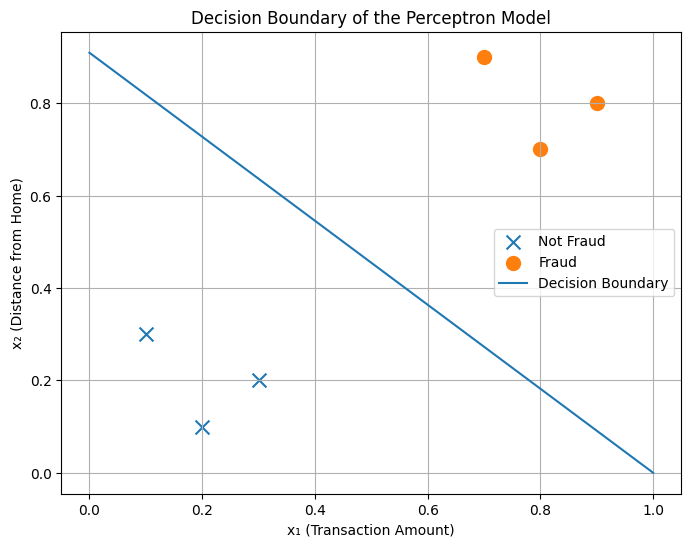

In [51]:
# Decision boundary
w1, w2 = model.coef_[0]
b = model.intercept_[0]

plt.figure(figsize=(8, 6))

class_0 = X_train[y_train == 0]
plt.scatter(class_0[:, 0], class_0[:, 1],
            marker='x', s=100, label='Not Fraud')

class_1 = X_train[y_train == 1]
plt.scatter(class_1[:, 0], class_1[:, 1],
            marker='o', s=100, label='Fraud')

x1_range = np.linspace(0, 1, 100)
x2_boundary = -(w1 / w2) * x1_range - (b / w2)

plt.plot(x1_range, x2_boundary, label='Decision Boundary')

plt.xlabel('x₁ (Transaction Amount)')
plt.ylabel('x₂ (Distance from Home)')
plt.title('Decision Boundary of the Perceptron Model')
plt.legend()
plt.grid(True)
plt.show()

In [44]:
#C)

In [50]:
X_new = np.array([[0.6, 0.5]])
prediction = model.predict(X_new)

if prediction[0] == 1:
    print("Fraud")
else:
    print("Not Fraud")


Fraud
